In [1]:
import numpy as np

data = np.load('octmnist.npz')
print("Keys in octmnist.npz: ", data.files)

for k in data.files:
    arr = data[k]
    print(f"{k:>12}: shape = {arr.shape}")

train_images = data["train_images"]
train_labels = data["train_labels"].ravel()

val_images = data["val_images"]
val_labels = data["val_labels"].ravel()

test_images = data["test_images"]
test_labels = data["test_labels"].ravel()

Keys in octmnist.npz:  ['train_images', 'val_images', 'test_images', 'train_labels', 'val_labels', 'test_labels']
train_images: shape = (97477, 28, 28)
  val_images: shape = (10832, 28, 28)
 test_images: shape = (1000, 28, 28)
train_labels: shape = (97477, 1)
  val_labels: shape = (10832, 1)
 test_labels: shape = (1000, 1)


In [2]:
from utils import stratified_subset

x_tr, y_tr = stratified_subset(train_images, train_labels, 22000)
x_va, y_va = stratified_subset(val_images, val_labels, 2000)

In [3]:
from sklearn.utils.class_weight import compute_sample_weight
from sklearn import set_config

sample_weights = compute_sample_weight(class_weight="balanced", y=y_tr)
sample_weights_valid = compute_sample_weight(class_weight="balanced", y=y_va)

In [4]:
from sklearn.ensemble import AdaBoostClassifier, StackingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler, FunctionTransformer, MinMaxScaler
from sklearn.kernel_approximation import Nystroem
from sklearn.pipeline import Pipeline
from utils import median, avg_2x2_pool, flatten_data
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

rf_pipe = Pipeline([
    ("med",   FunctionTransformer(median, validate=False)),
    ("avg14", FunctionTransformer(avg_2x2_pool, validate=False)),
    ("flat",  FunctionTransformer(flatten_data, validate=False)),
    ("rf", RandomForestClassifier(
        max_depth=None,
        max_features=.25,
        min_samples_leaf=1,
        min_samples_split=10,
        n_estimators=200,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

svc_pipe = Pipeline([
    ("med",   FunctionTransformer(median, validate=False)),
    ("avg14", FunctionTransformer(avg_2x2_pool, validate=False)),
    ("flat",  FunctionTransformer(flatten_data, validate=False)),
    ("scale", MinMaxScaler()),
    ("kernel", Nystroem(
        kernel="rbf",
        gamma=None,
        n_components=500,
        random_state=42,
    )),
    ("svc", LinearSVC(
        dual=False,
        max_iter=4000,
        class_weight="balanced"
    ))
])

stacking_clf = StackingClassifier(
    estimators=[
        ("rf", rf_pipe),
        ("svc", svc_pipe)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=2,
    verbose=2
)

class_names = [
    "Normal",
    "CNV",
    "DME",
    "Drusen"
]

In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold
from sklearn.preprocessing import label_binarize
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, auc
from sklearn.model_selection import cross_val_score
import time
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, auc, f1_score
)

def evaluate_on_test(name, model, x_tr, y_tr, x_te, y_te, class_names=None, cross_validate=False):

    y_tr = np.ravel(y_tr)
    y_te = np.ravel(y_te)

    k_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    if cross_validate:
        cv_scores = cross_validate(
            model,
            x_tr,
            y_tr,
            cv=k_fold,
            scoring=["accuracy", "precision_weighted", "f1_weighted"],
            n_jobs=-1
        )

        print("Cross-Validation Results:")
        print(f"Accuracy:  {cv_scores['test_accuracy'].mean():.4f} ± {cv_scores['test_accuracy'].std():.4f}")
        print(f"Precision: {cv_scores['test_precision_weighted'].mean():.4f}")
        print(f"F1:    {cv_scores['test_f1_weighted'].mean():.4f}")

    t1 = time.time()
    model.fit(x_tr, y_tr)
    t2 = time.time()

    y_pred = model.predict(x_te)

    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average="weighted", zero_division=1)
    f1 = f1_score(y_te, y_pred, average="weighted", zero_division=1)

    result = {
        "Model": name,
        "CV Accuracy": cv_scores["test_accuracy"].mean() if cross_validate else None,
        "CV Precision": cv_scores["test_precision_weighted"].mean() if cross_validate else None,
        "CV Recall": cv_scores["test_f1_weighted"].mean() if cross_validate else None,
        "Train Time (s)": t2 - t1,
        "Test Accuracy": acc,
        "Test Precision": prec,
        "Test Recall": f1
    }

    print(f"\nModel: {name}")
    print(f"Training Time: {t2 - t1:.3f}s")
    print(f"Test Accuracy:  {acc:.4f}")
    print(f"Test Precision: {prec:.4f}")
    print(f"Test Recall:    {f1:.4f}")

    cm = confusion_matrix(y_te, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    y_score = None
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(x_te)
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(x_te)

    if y_score is not None:
        classes = np.unique(y_te)
        y_te_bin = label_binarize(y_te, classes=classes)

        auc_macro = roc_auc_score(y_te_bin, y_score, multi_class="ovr", average="macro")
        auc_weighted = roc_auc_score(y_te_bin, y_score, multi_class="ovr", average="weighted")

        result["Test AUC Macro"] = auc_macro
        result["Test AUC Weighted"] = auc_weighted

        print(f"Test AUC Macro:    {auc_macro:.4f}")
        print(f"Test AUC Weighted: {auc_weighted:.4f}")

        plt.figure(figsize=(8, 6))
        for i in range(y_te_bin.shape[1]):
            fpr, tpr, _ = roc_curve(y_te_bin[:, i], y_score[:, i])
            roc_auc_val = auc(fpr, tpr)
            label = class_names[i] if class_names is not None else f"Class {i}"
            plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc_val:.3f})")

        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curves - {name}")
        plt.legend()
        plt.show()
    else:
        result["Test AUC Macro"] = np.nan
        result["Test AUC Weighted"] = np.nan
        print("ROC/AUC not available for this model.")

    return result
'''
evaluate_on_test(
    name="Stacking_clf",
    model=stacking_clf,
    x_tr=x_tr,
    y_tr=y_tr,
    x_te=x_va,
    y_te=y_va,
    class_names=class_names
)
'''

'\nevaluate_on_test(\n    name="Stacking_clf",\n    model=stacking_clf,\n    x_tr=x_tr,\n    y_tr=y_tr,\n    x_te=x_va,\n    y_te=y_va,\n    class_names=class_names\n)\n'

Class Weights improved it. Let's test on the entire Dataset now.


Model: Stacking_clf
Training Time: 2148.728s
Test Accuracy:  0.5940
Test Precision: 0.6297
Test Recall:    0.5256


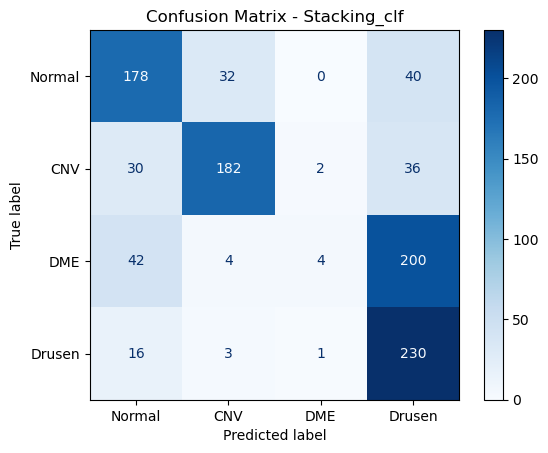

Test AUC Macro:    0.8550
Test AUC Weighted: 0.8550


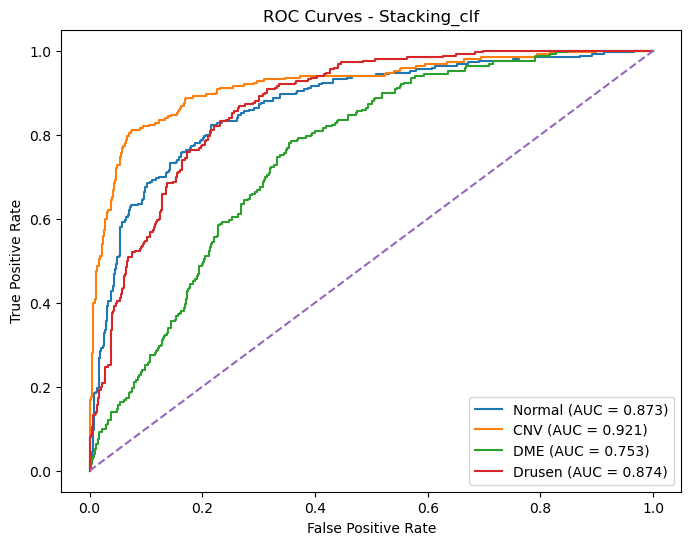

{'Model': 'Stacking_clf',
 'CV Accuracy': None,
 'CV Precision': None,
 'CV Recall': None,
 'Train Time (s)': 2148.7277541160583,
 'Test Accuracy': 0.594,
 'Test Precision': 0.6296690925173897,
 'Test Recall': 0.5255850682370576,
 'Test AUC Macro': 0.854992,
 'Test AUC Weighted': 0.854992}

In [8]:
evaluate_on_test(
    name="Stacking_clf",
    model=stacking_clf,
    x_tr=train_images,
    y_tr=train_labels,
    x_te=test_images,
    y_te=test_labels,
    class_names=class_names
)

In [ ]:
#We will now compare this performance with a voting clf of the same 3 models
#We will keep preprocessing to a minimum to evaluate if we are losing information
from sklearn.ensemble import VotingClassifier, AdaBoostClassifier 
from sklearn.svm import SVC

rf = Pipeline([
    ("flat", FunctionTransformer(flatten_data, validate=False)),
    ("model", RandomForestClassifier(
        max_depth=None,
        max_features=.25,
        min_samples_leaf=1,
        min_samples_split=10,
        n_estimators=200,
        random_state=42,
        class_weight="balanced_subsample", #Introducing class weights as professor recommended
        n_jobs=-1    
    ))
])

svc = Pipeline([
    ("flat", FunctionTransformer(flatten_data, validate=False)),
    ("model", SVC(kernel="rbf", 
                  probability=True, 
                  class_weight="balanced"))
])

ada = Pipeline([
    ("flat", FunctionTransformer(flatten_data, validate=False)),
    ("model", AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, class_weight="balanced"),
    n_estimators=200,
    learning_rate=1,
    random_state=42,
))
])

voting = VotingClassifier(
    estimators=[
        ("rf", rf),
        ("svc", svc),
        ("ada", ada)
    ],
    voting='soft'
)

evaluate_on_test(
    name="voting_clf",
    model=voting,
    x_tr=train_images,
    y_tr=train_labels,
    x_te=test_images,
    y_te=test_labels,
    class_names=class_names,
    cross_validate=False
)